# Evaluate DES galaxy, shear and cluster covariances with CoCoA

Compute **real-space and Fourier-space 3x2pt covariances**, keeping the
Gaussian (G), super-sample (SSC), connected non-Gaussian (cNG), and total
matrices separately. G describes products of power spectra and catalog
noise. SSC describes changes induced by density fluctuations larger than
the footprint. cNG describes the remaining connected four-point signal.

The first sections use six lens and four source bins. The final section
adds the angular cluster 6x2pt+N forecast, with three observed-redshift
bins and four richness bins. Its count crosses contain SSC only and its
cluster cNG uses the explicitly documented biased-tracer approximation.
The calculations share the physics in `cosmolike_notebook_utils.covariance`;
C++ exposes whole Gaussian matrices and individual C components. The C
loops use OpenMP and SIMDe; BLAS uses one thread.

**Forecast model:** massless neutrinos, linear galaxy bias, zero IA,
magnification and RSD, Limber spectra, a spherical-cap footprint and the
five-term halo trispectrum. SSC uses an isotropic halo response transferred
to the nonlinear power, with galaxy survey-mean subtraction. These choices
do not reproduce every approximation in a supplied survey covariance.
No likelihood data or covariance is loaded or replaced.

Follow [the covariance guide](covariance/README.md) to compile and start
this notebook. The physics decomposition follows
[Krause & Eifler, Appendix A](https://arxiv.org/abs/1601.05779) and
[Takada & Hu](https://arxiv.org/abs/1302.6994).


In [1]:
import os
from pathlib import Path
import sys

# Set the BLAS policy before importing numerical libraries. OpenMP workers
# belong to the explicit C loops, not to nested BLAS matrix operations.
os.environ["OPENBLAS_NUM_THREADS"] = "1"
root = Path(os.environ["ROOTDIR"])
project = root/"projects/des_cluster"
sys.path.insert(0, str(root/"external_modules/code/cosmolike_core"))
sys.path.insert(0, str(root/"external_modules/code/CAMB"))
sys.path.insert(0, str(project/"interface"))
sys.path.insert(0, str(project/"covariance"))

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib
import numpy as np
from threadpoolctl import threadpool_limits
import cosmolike_des_cluster_interface as ci
import des_cluster_covariance as survey
from cosmolike_notebook_utils import covariance as cov
from cosmolike_notebook_utils.covariance.forecast import save_forecast
from cosmolike_notebook_utils import plot_covariances as pcov

blas_limit = threadpool_limits(limits=1, user_api="blas")
ci.set_omp_threads(n=8)

# Figure appearance belongs to the notebook, not the shared plotters.
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'


## Survey inputs and one accuracy control

The example uses the six MagLim lens and four source distributions,
number densities and shape dispersion adopted by this project's
[synthetic-data generator](scripts/make_synthetic_data.py).
The quadrature shape dispersion 0.384666 is divided by $\sqrt{2}$
to obtain the per-component input.
These galaxy and shear blocks are part of the joint analysis described by
[DES, arXiv:2503.13631](https://arxiv.org/abs/2503.13631).
The final section adds the selected cluster population and its joint
angular covariance. The Fourier section remains galaxy/shear only.

| Measurement | Layout |
| --- | --- |
| Lens and source bins | 6 lenses, 4 sources |
| Angular bins | 20 logarithmic bins, 2.5–250 arcminutes |
| Integer Fourier bands | 15 bands, multipoles 30–4000 |
| Real-space vector | 1,000 entries |
| Fourier vector | 600 entries |

Internal spectra retain all crossed pairs, including pairs excluded from
measured rows. Inspect the printed settings before interpreting the noise.

`accuracy_boost` raises integration resolution together. Use 1, 2, 4 or 8;
extend `boosts` for stronger refinement. CAMB accuracy and measurement bins
stay fixed. The highest tested boost is a comparison reference, not a
certified inference setting.


In [2]:
boosts = [1, 2]
settings = survey.configuration(accuracy_boost=boosts[0])
camb_tables = survey.initialize(interface=ci, settings=settings)
ci.set_omp_threads(n=8)

for name in ("area_deg2", "lens_density_arcmin2", "source_density_arcmin2",
             "sigma_e_component", "accuracy_boost", "ng_ell_nodes"):
    print(name, settings[name])


def progress(stage, elapsed):
    """Print completed integration stages without starting another calculation."""
    print(f"{elapsed:8.2f} s  {stage}")


area_deg2 4143.0
lens_density_arcmin2 [0.138, 0.1016, 0.1071, 0.1381, 0.1054, 0.1045]
source_density_arcmin2 [2.1402, 2.14455, 2.1518, 2.11845]
sigma_e_component [0.27199993709190445, 0.27199993709190445, 0.27199993709190445, 0.27199993709190445]
accuracy_boost 1
ng_ell_nodes 16


## Real-space Gaussian, SSC and connected covariance

All angular bins of one observable are consecutive. Observable rows run
through $\xi_+$, $\xi_-$, $\gamma_t$, then $w$. Pure white noise has an
infinite harmonic tail, so the real-space calculation uses analytic pair
noise; signal and mixed noise retain the finite multipole sum.

The following loop holds the physical inputs fixed and raises only the
covariance resolution. Each returned dictionary contains `gaussian`,
`ssc`, `cng`, `total`, mean `signal`, row labels and resolved `settings`.


Real-space accuracy boost 1
    0.18 s  all_pairs_limber_spectra


    0.21 s  angular_and_mask_geometry


    0.52 s  gaussian_blocks
    0.53 s  observable_signal
    0.55 s  Matter shell 1/448
    0.68 s  Matter shell 33/448


    0.83 s  Matter shell 65/448


    1.13 s  Matter shell 97/448
    1.31 s  Matter shell 129/448


...

   23.65 s  Matter shell 801/896


   24.47 s  Matter shell 833/896


   25.41 s  Matter shell 865/896


   26.44 s  shared_halo_response_and_trispectrum


   28.33 s  ssc_and_connected_projection
   28.33 s  total


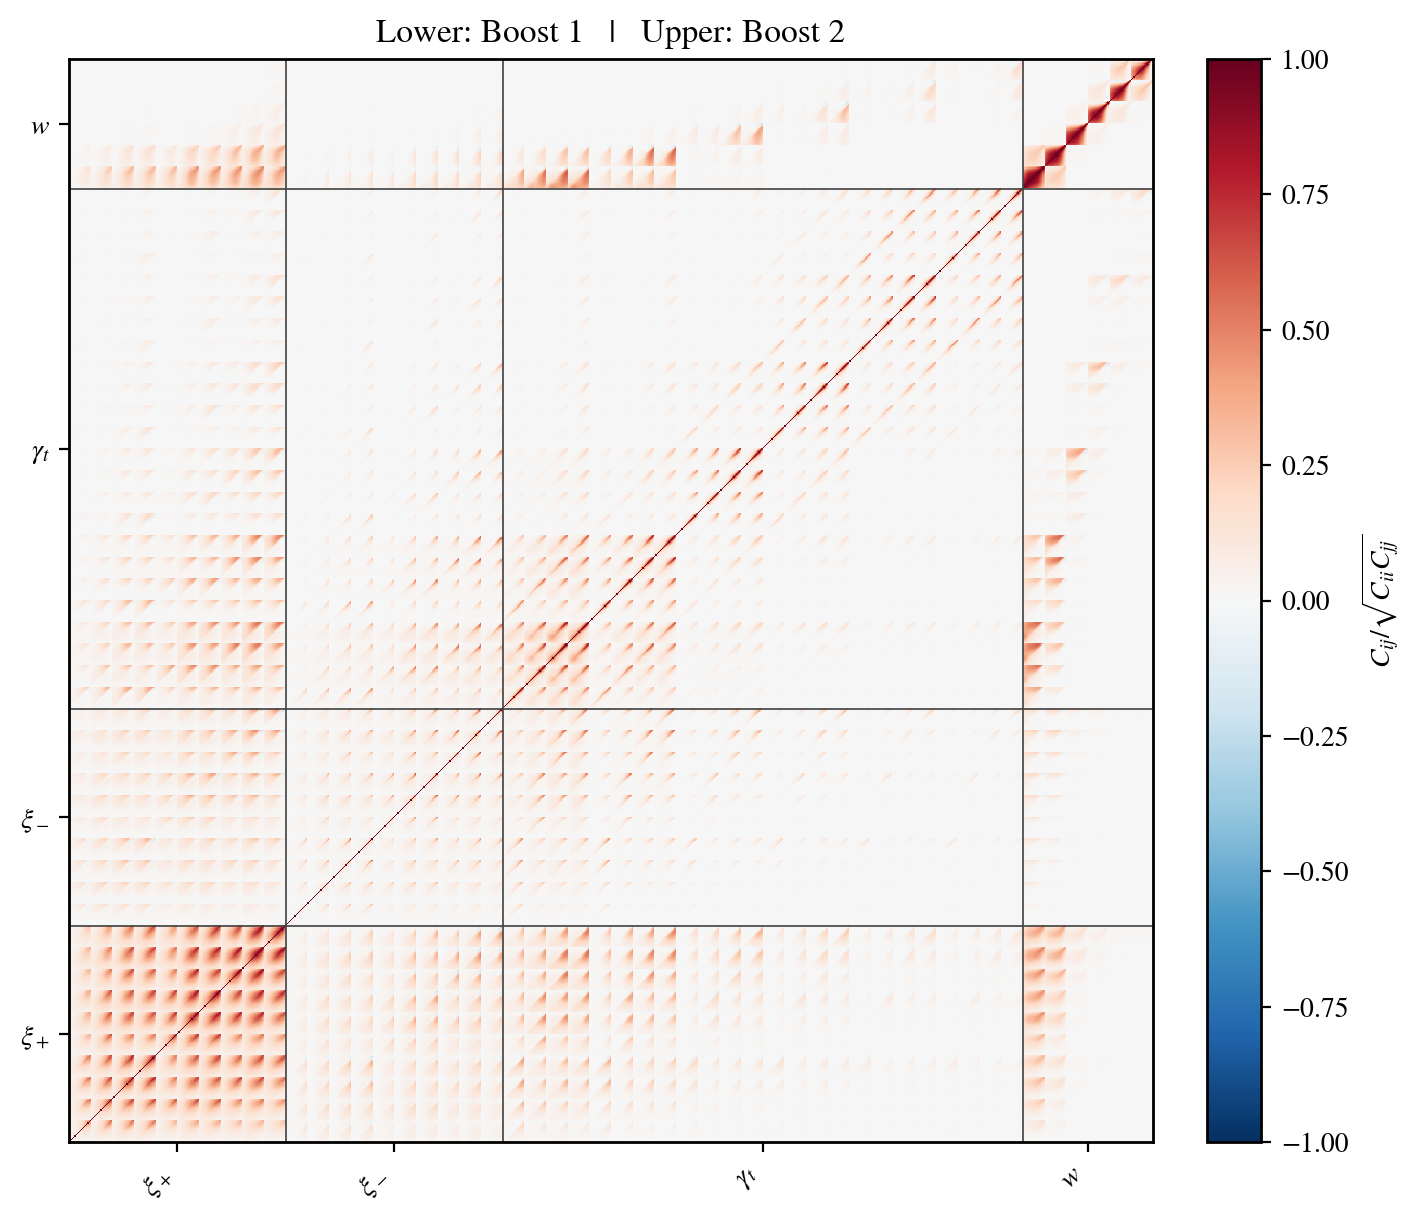

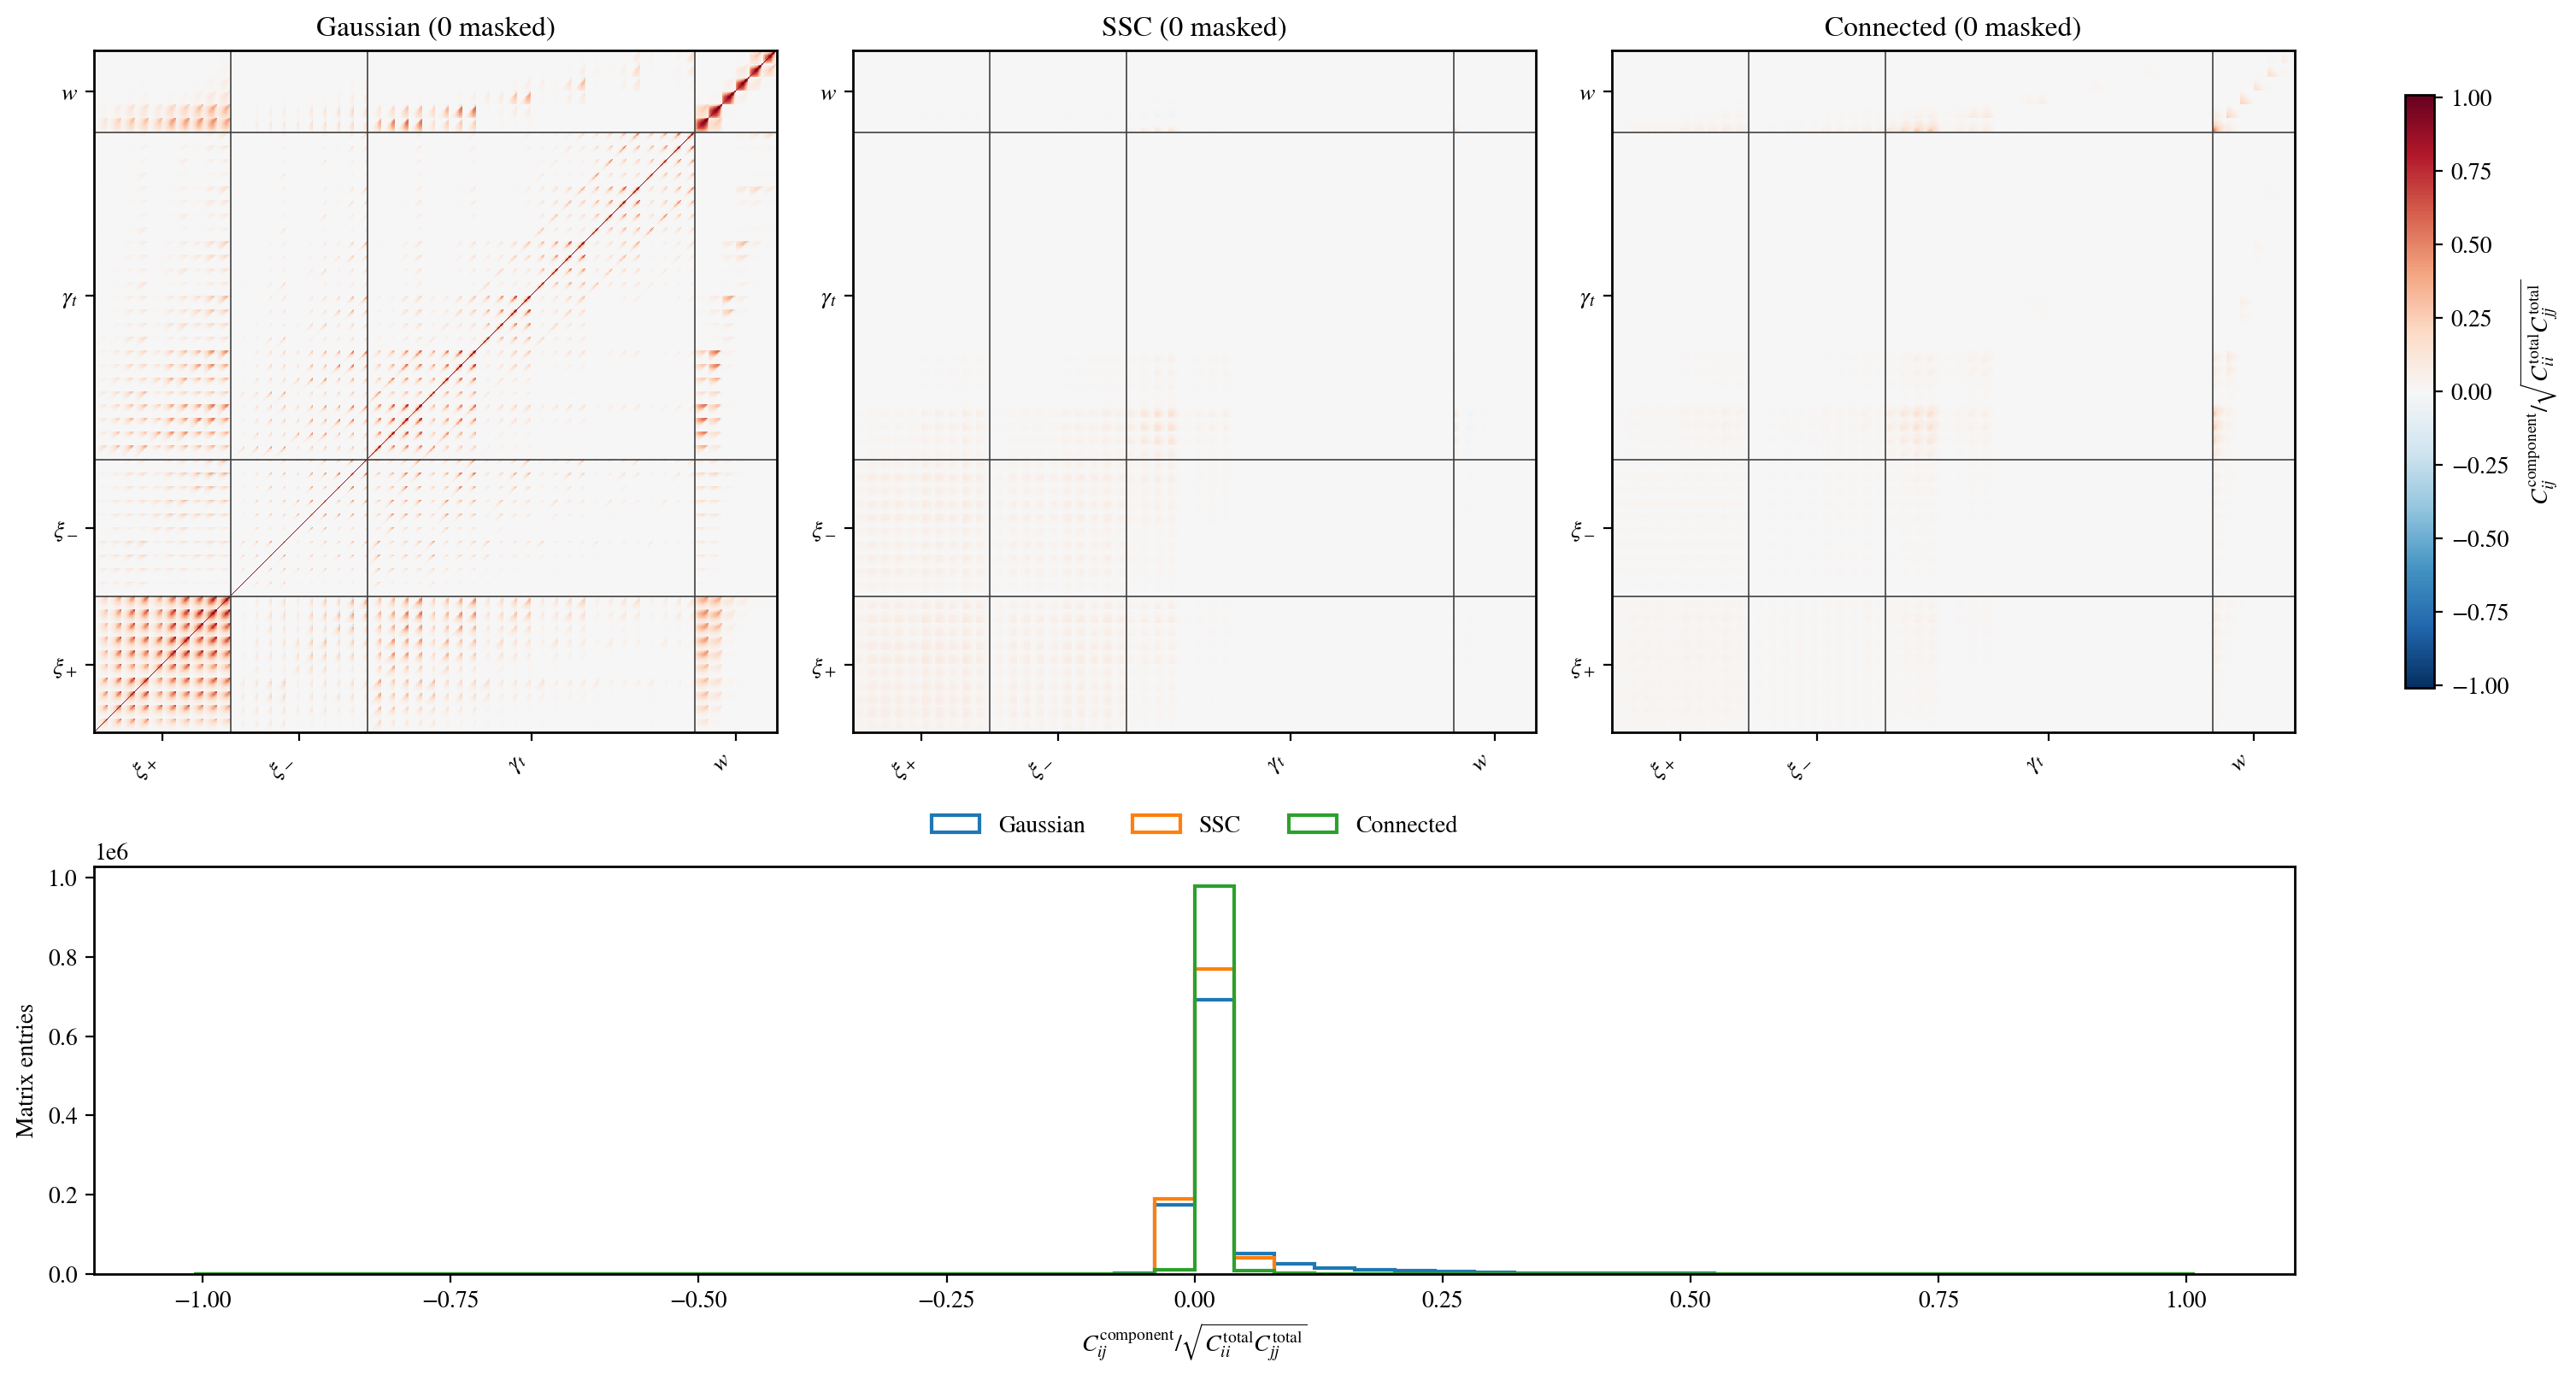

In [3]:
real_results = {}
for boost in boosts:
    refined = dict(settings)
    refined.update(cov.covariance_accuracy(accuracy_boost=boost))
    print("Real-space accuracy boost", boost)
    real_results[boost] = survey.compute(
        interface=ci, settings=refined, space="real", progress=progress
    )

reference_boost = boosts[-1]
real = real_results[reference_boost]
nbin = len(real["coordinate"])
real_sizes = []
for probe in (0, 1, 2, 3):
    real_sizes.append(int(np.sum(real["rows"][:, 0] == probe))*nbin)
real_labels = [r"$\xi_+$", r"$\xi_-$", r"$\gamma_t$", r"$w$"]
pcov.plot_correlation(
    covariance=real_results[boosts[0]]["total"],
    covariance_ref=real["total"], block_sizes=real_sizes,
    block_labels=real_labels,
    labels=(f"Boost {boosts[0]}", f"Boost {reference_boost}"),
)
pcov.plot_covariance_components(
    total=real["total"],
    components={
        "Gaussian": real["gaussian"],
        "SSC": real["ssc"],
        "Connected": real["cng"],
    },
    block_sizes=real_sizes, block_labels=real_labels,
    normalization="diagonal",
)


## Fourier bandpowers

A band averages its integer multipoles with weight $2\ell+1$, their number
of harmonic modes. The Gaussian term includes finite-band white noise.
SSC and cNG use the same matter calculation as the angular forecast,
projected through band weights on both matrix axes.

There is one shear E-mode spectrum per source pair; do not duplicate it
for $\xi_+$ and $\xi_-$. Fourier means average the core spectra directly.
Real-space means include the extra source-leg factor needed to match
Cocoa's angular transformation convention. Each space applies its chosen
normalization consistently to G, SSC and cNG. Thus the examples should not
be compared as if their vectors contained the same measurements.


Fourier accuracy boost 1
    0.09 s  all_pairs_limber_spectra
    0.09 s  angular_and_mask_geometry


    0.37 s  gaussian_blocks
    0.37 s  observable_signal
    0.38 s  Matter shell 1/448


    0.58 s  Matter shell 33/448


    1.02 s  Matter shell 65/448


    1.55 s  Matter shell 97/448
    1.74 s  Matter shell 129/448


...

   22.30 s  Matter shell 769/896


   22.81 s  Matter shell 801/896


   23.33 s  Matter shell 833/896


   23.85 s  Matter shell 865/896


   24.39 s  shared_halo_response_and_trispectrum
   24.55 s  ssc_and_connected_projection
   24.55 s  total


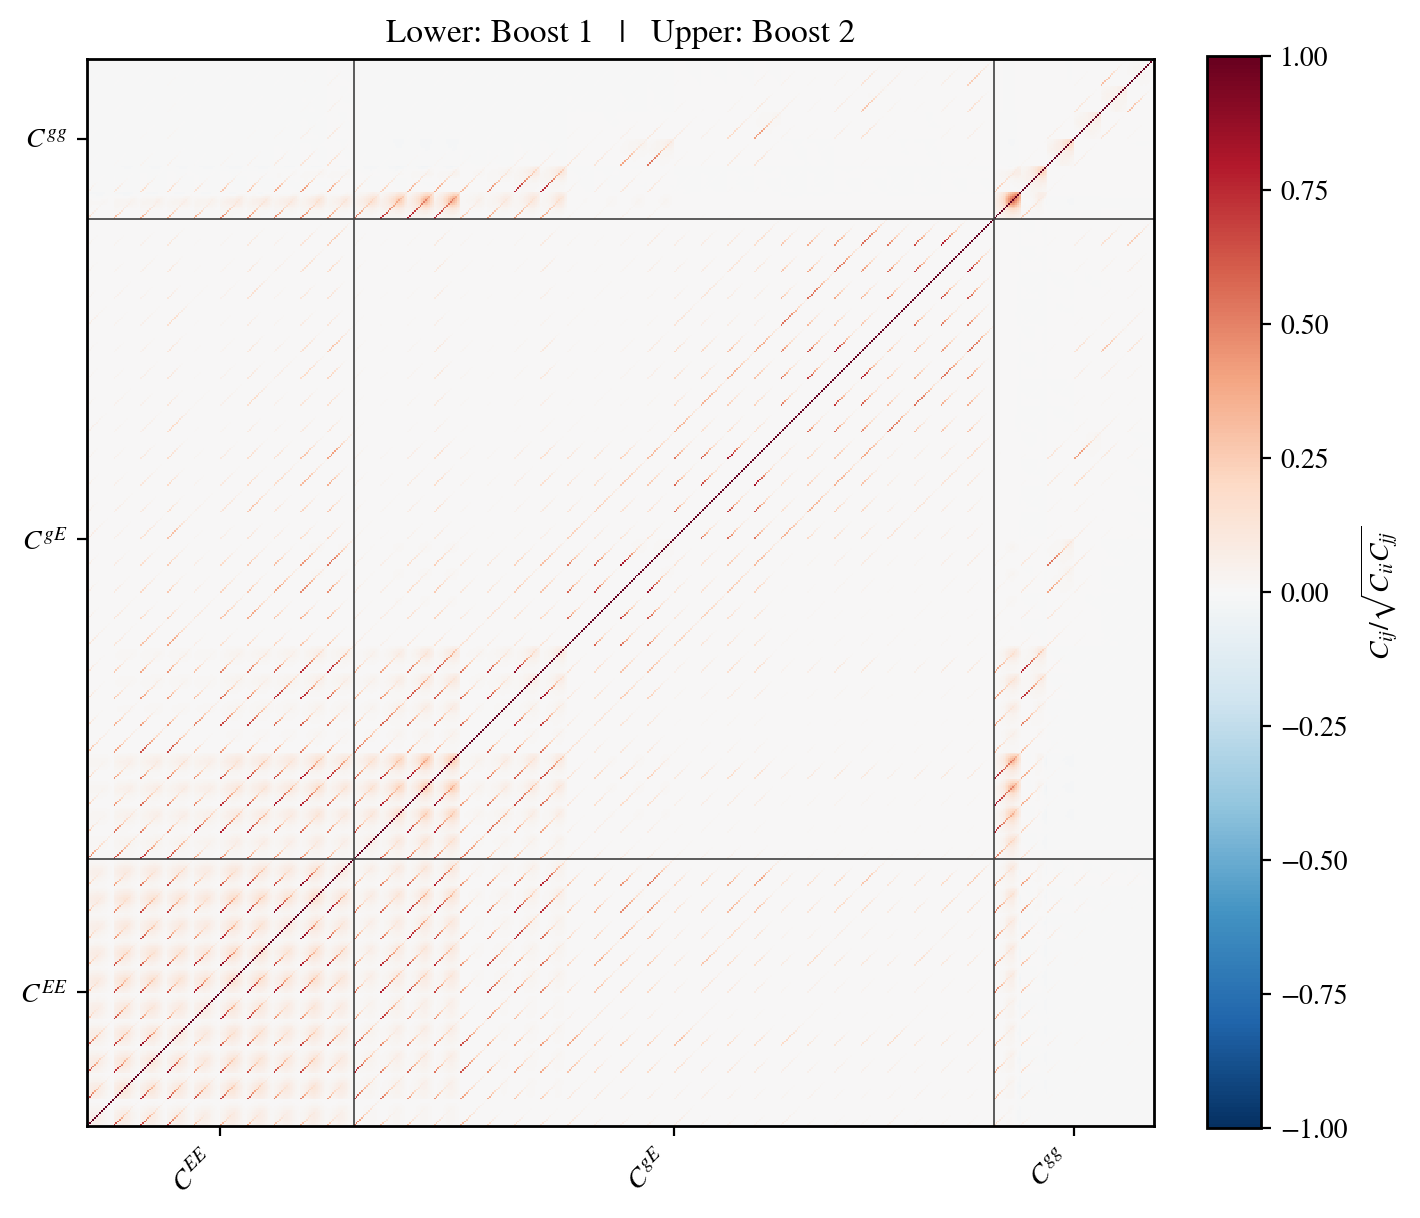

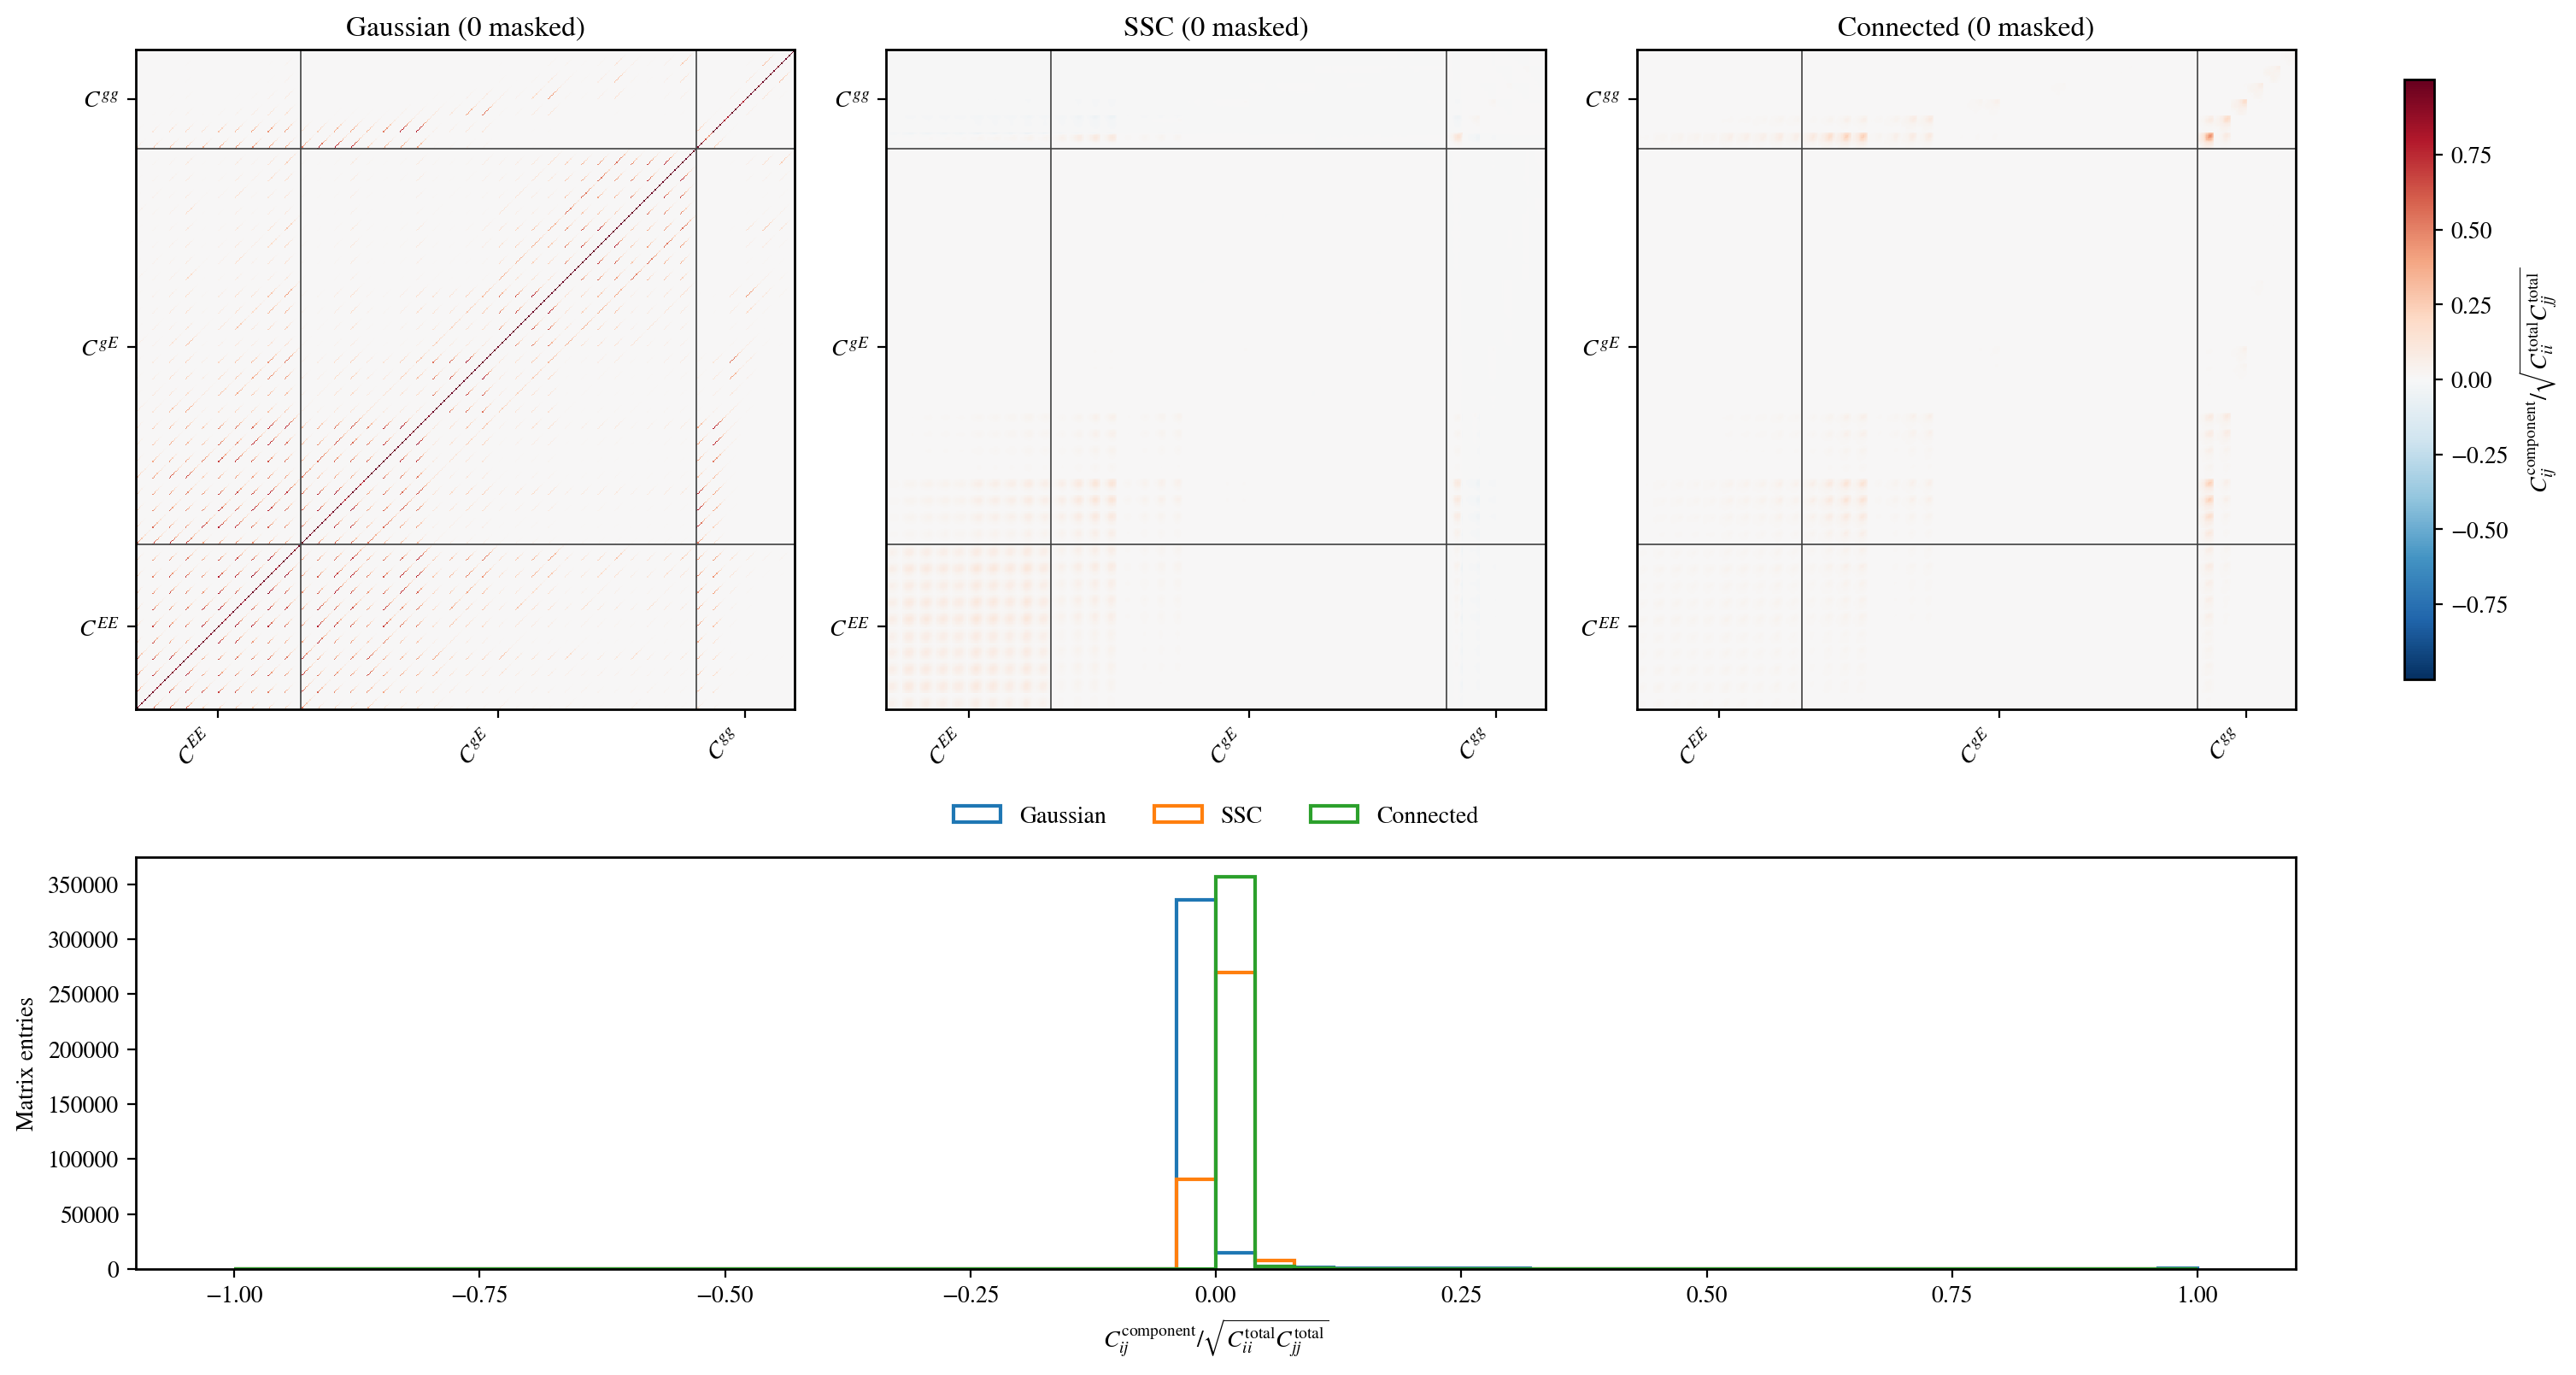

In [4]:
fourier_results = {}
for boost in boosts:
    refined = dict(settings)
    refined.update(cov.covariance_accuracy(accuracy_boost=boost))
    print("Fourier accuracy boost", boost)
    fourier_results[boost] = survey.compute(
        interface=ci, settings=refined, space="fourier", progress=progress
    )

fourier = fourier_results[reference_boost]
nband = len(fourier["coordinate"])
fourier_sizes = []
for probe in (0, 2, 3):
    fourier_sizes.append(int(np.sum(fourier["rows"][:, 0] == probe))*nband)
fourier_labels = [r"$C^{EE}$", r"$C^{gE}$", r"$C^{gg}$"]
pcov.plot_correlation(
    covariance=fourier_results[boosts[0]]["total"],
    covariance_ref=fourier["total"], block_sizes=fourier_sizes,
    block_labels=fourier_labels,
    labels=(f"Boost {boosts[0]}", f"Boost {reference_boost}"),
)
pcov.plot_covariance_components(
    total=fourier["total"],
    components={
        "Gaussian": fourier["gaussian"],
        "SSC": fourier["ssc"],
        "Connected": fourier["cng"],
    },
    block_sizes=fourier_sizes, block_labels=fourier_labels,
    normalization="diagonal",
)


## Positivity and accuracy changes

A covariance must give nonnegative variance to every linear combination
of measurements. A positive diagonal alone does not establish this. The
next cells report the total matrix's smallest correlation eigenvalue,
without clipping eigenvalues or adding diagonal corrections.

Generalized eigenvalues solve $C_bv=\lambda C_{\rm ref}v$ and bound variance
ratios in every direction. The diagonal comparison measures changes in
individual error bars. The two reported change columns are fractions: 0.01
means 1%. The error-bar plots below convert those fractions to percent. Both are diagnostics; final numerical acceptance
needs stable parameter errors and marginalized Fisher Figure of Merit at
representative cosmologies. The data-vector $|\Delta\chi^2|<0.2$ condition
is not a covariance convergence test.

The correlation panels follow
[Friedrich et al., Fig. 6](https://arxiv.org/abs/2012.08568). Component maps
and histograms adapt [Barreira, Krause & Schmidt, Fig. 1](https://arxiv.org/abs/1807.04266).
The plots use the computed matrices; they retain signs and do not invent
missing components. Grey pixels mark undefined normalizations.


In [5]:
for space, results in (("Real", real_results), ("Fourier", fourier_results)):
    reference = results[reference_boost]["total"]
    print(space, "boost | minimum correlation eigenvalue |",
          "max variance change | max error change")
    for boost in boosts:
        matrix = results[boost]["total"]
        modes = cov.covariance_modes(matrix=matrix)
        print("  Positive definite:", modes["positive_definite"])
        comparison = cov.compare_covariances(matrix=matrix, reference=reference)
        errors = np.sqrt(np.diag(matrix)/np.diag(reference))
        print(boost, modes["correlation_eigenvalues"][0],
              comparison["maximum_fractional_variance_change"],
              np.max(np.abs(errors-1)))


Real boost | minimum correlation eigenvalue | max variance change | max error change
  Positive definite: True


1 0.007512621299584182 0.17528353827067766 0.02328988969687651


  Positive definite: True


2 0.007512681964099819 1.6009416015094757e-13 0.0
Fourier boost | minimum correlation eigenvalue | max variance change | max error change
  Positive definite: True


1 0.01079373582864107 0.16246682843294558 0.048115317586815864
  Positive definite: True
2 0.010803950752172836 3.419486915845482e-14 0.0


## Error bars for the first source bin

The full matrices above retain every bin pair. For readable error-bar
panels, select the first source auto-correlation: $\xi_+$ and $\xi_-$ in
real space, and its E-mode bands in Fourier space. Each curve shows the
change in $\sqrt{C_{ii}}$ relative to the highest tested boost.


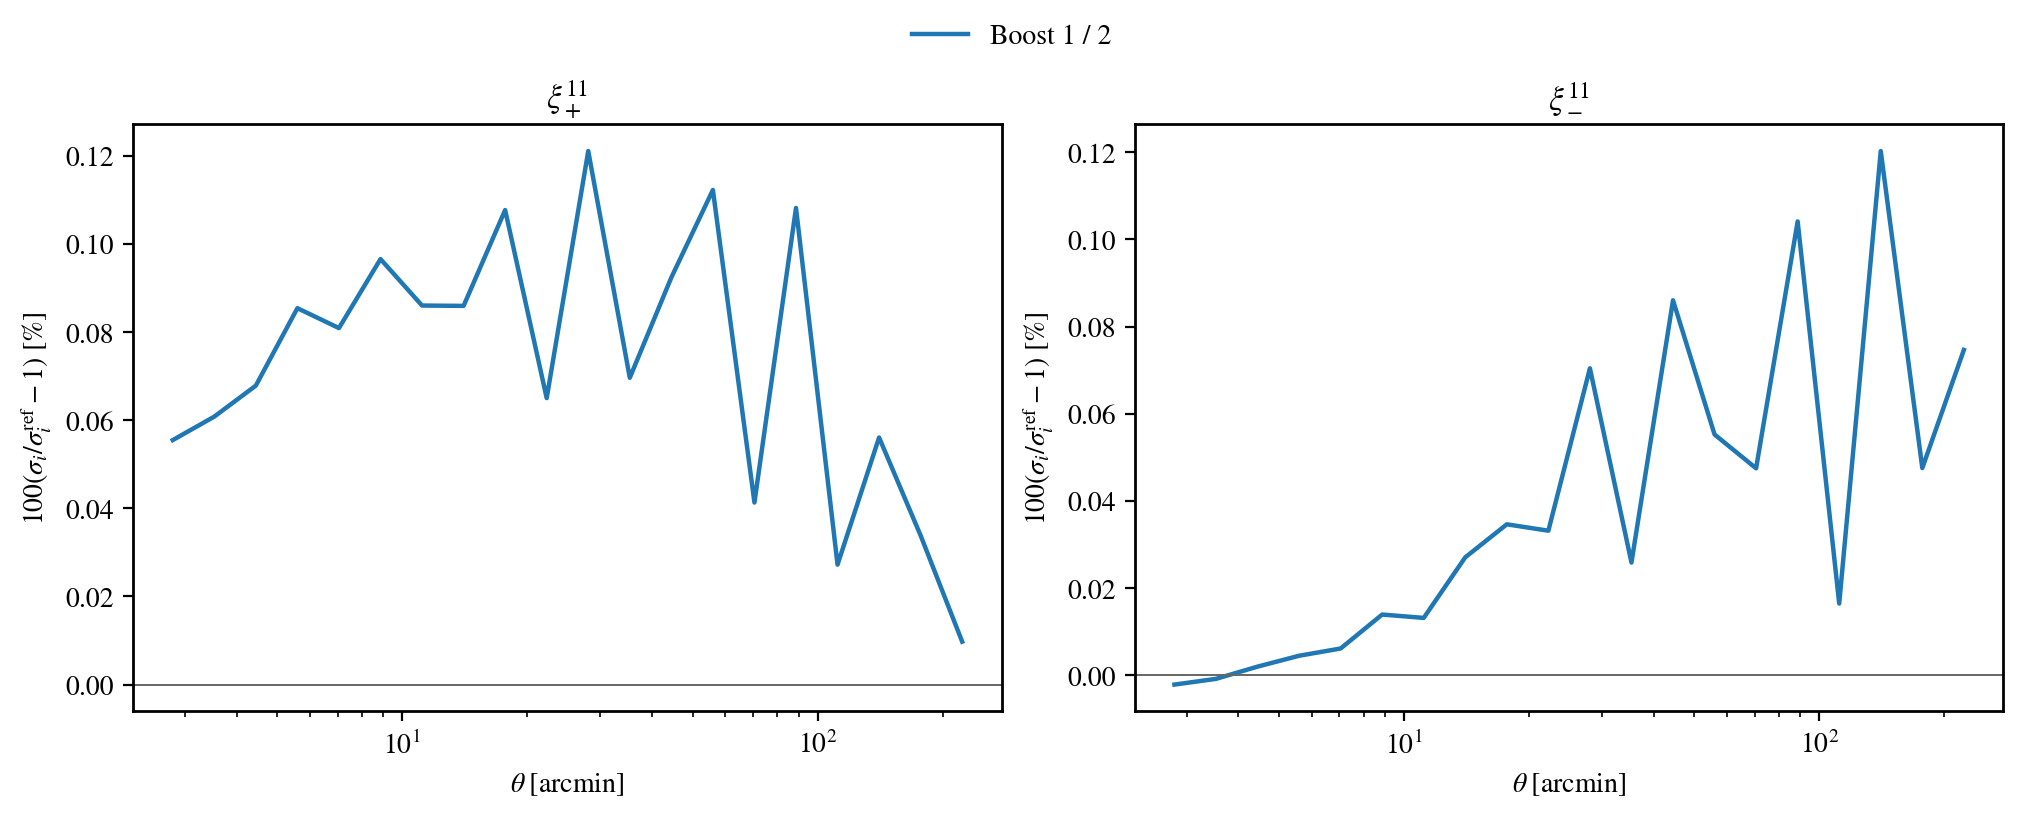

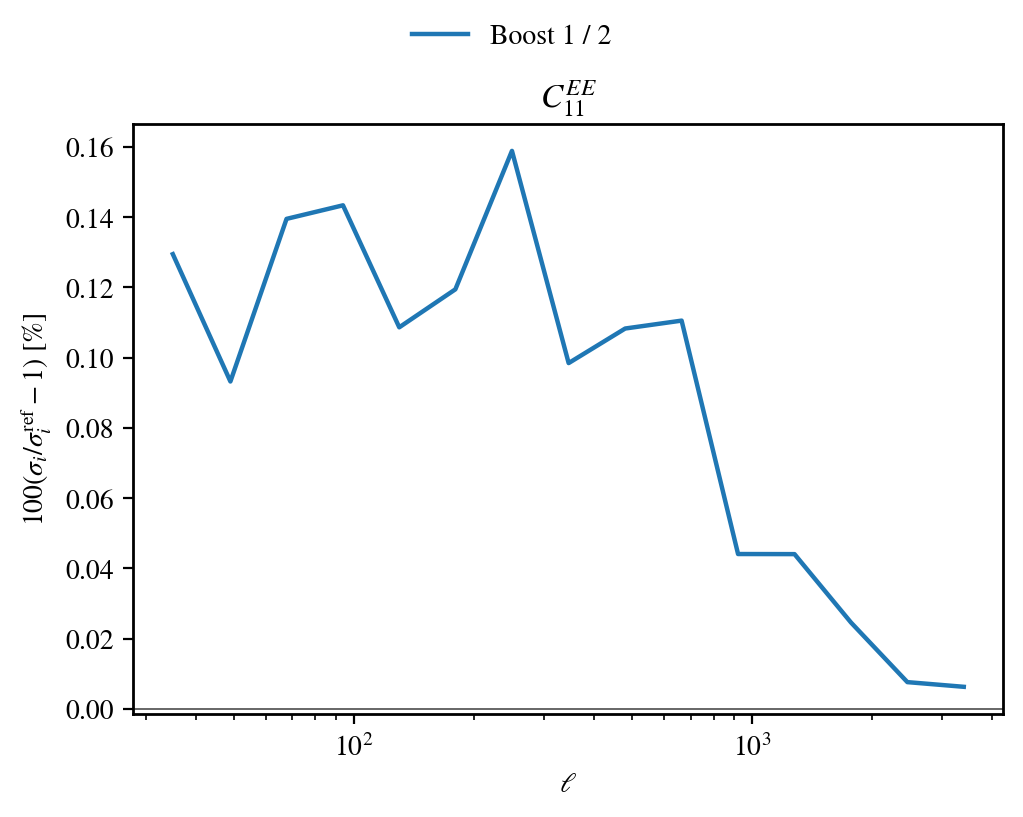

In [6]:
nlens = len(settings["lens_density_arcmin2"])
for space, results in (("Real", real_results), ("Fourier", fourier_results)):
    selected = results[reference_boost]
    rows = selected["rows"]
    source_rows = np.flatnonzero((rows[:, 1] == nlens) & (rows[:, 2] == nlens))
    nbin = len(selected["coordinate"])
    indices = (source_rows[:, None]*nbin+np.arange(nbin)).ravel()
    reference = selected["total"][np.ix_(indices, indices)]
    curves = {}
    for boost in boosts[:-1]:
        curves[f"Boost {boost} / {reference_boost}"] = (
            results[boost]["total"][np.ix_(indices, indices)]
        )
    labels = [r"$C^{EE}_{11}$"]
    if space == "Real":
        labels = [r"$\xi_+^{11}$", r"$\xi_-^{11}$"]
    pcov.plot_covariance_diagonal(
        theta_arcmin=selected["coordinate"], covariances=curves,
        panel_labels=labels, covariance_ref=reference,
        coordinate_label=selected["coordinate_label"],
    )


## Inspect the C++ interface and individual components

`ci.covariance_gaussian_real` and `ci.covariance_gaussian_fourier` accept
complete supplied field spectra, noise and measurement operators and
return owned NumPy matrices. Low-level functions expose the Wick products,
projection, halo moments, responses and mask variance for independent tests.
Their help text gives dimensions and units. The example below inspects
interfaces without altering the installed cosmology.


In [7]:
help(ci.covariance_gaussian_fourier)
help(ci.covariance_project)
help(ci.covariance_halo_response)


Help on built-in function covariance_gaussian_fourier in module cosmolike_des_cluster_interface:

covariance_gaussian_fourier(...) method of builtins.PyCapsule instance
    covariance_gaussian_fourier(spectra: numpy.ndarray[numpy.float64], noise: numpy.ndarray[numpy.float64], pairs: numpy.ndarray[numpy.int32], operators: numpy.ndarray[numpy.float64], ell_min: int, area_sr: float) -> numpy.ndarray[numpy.float64]
    
    Compute a Gaussian bandpower matrix from supplied field spectra.
    
    spectra[ell,field,field] contains observed signal on consecutive integer
    multipoles starting at ell_min>=0. noise[field] is independent white
    shot/shape power. pairs[observable,2] contains field IDs (A,B).
    operators[band,ell] supplies normalized band weights; the supplied bands
    may overlap. area_sr is the common survey area in steradians.
    Use contiguous float64 arrays and int32 pairs. Internal crossed spectra
    are required even when excluded from the measured bandpower vecto

## Save and inspect the computed matrices

The next cell writes the highest tested boost to two NumPy archives in
`covariance/`, and saves the CAMB tables separately. Each forecast archive
contains separate components, total, row map, mean signal, coordinates,
radial geometry and resolved numerical/physical settings. The paths refer
to these computed outputs, not the project's supplied data files.

For stronger refinement, extend `boosts` to `[1, 2, 4]` or `[1, 2, 4, 8]`
and rerun the notebook. Outputs at the same names are replaced. Refine
the physical model separately from its numerical integration.


In [8]:
save_forecast(result=real, filename=project/"covariance/forecast_real.npz")
save_forecast(result=fourier, filename=project/"covariance/forecast_fourier.npz")
np.savez(file=project/"covariance/forecast_camb.npz", **camb_tables)

with np.load(project/"covariance/forecast_real.npz", allow_pickle=False) as saved:
    print("Saved arrays:", saved.files)
    print("Total covariance shape:", saved["total"].shape)


Saved arrays: ['gaussian', 'ssc', 'cng', 'total', 'signal', 'rows', 'coordinate', 'coordinate_label', 'geometry', 'coarse_ell', 'pair_area_sr2', 'settings_json', 'stages_json']
Total covariance shape: (1000, 1000)


## Cluster 6x2pt + counts

The joint vector contains 2,800 two-point entries and 12 absolute counts,
in the order shear–shear, galaxy–shear, galaxy clustering, cluster–galaxy,
counts, cluster clustering, cluster lensing. The calculation retains all
internal cross-bin spectra and applies the same Y operator as the mean
model to every cluster-lensing covariance cross block.

This is a **limited-model forecast**. cNG treats cluster density as a
linearly biased matter tracer. Count cross covariance contains SSC only:
non-SSC count–spectrum terms and selected-cluster one-halo cNG corrections
are omitted. SSC includes the fixed-profile abundance response of the
cluster's own halo and the observed catalog normalization. These choices,
Limber, zero environmental selection correction and the massless model
must be assessed before inference. See the [cluster guide](covariance/README.md#joint).

This separate initialization uses the cluster adapter's recorded physical
inputs. Inspect the settings and saved omissions alongside the matrix.


In [9]:
import des_cluster_joint_covariance as joint_survey
from cosmolike_notebook_utils.covariance.forecast_cluster import (
    save_forecast as save_joint_forecast,
)

cluster_boosts = [1, 2]
cluster_settings = joint_survey.configuration(
    accuracy_boost=cluster_boosts[0], ytransform=True,
)
cluster_camb = joint_survey.initialize(interface=ci, settings=cluster_settings)
ci.set_omp_threads(n=8)
joint_results = {}
for boost in cluster_boosts:
    refined = dict(cluster_settings)
    refined.update(cov.covariance_accuracy(accuracy_boost=boost))
    print("Joint cluster accuracy boost", boost)
    joint_results[boost] = joint_survey.compute(
        interface=ci, settings=refined, progress=progress,
    )
joint = joint_results[cluster_boosts[-1]]
print("Joint shape:", joint["total"].shape)
print("Count means:", joint["mean_counts"])
print("Omitted physics:", joint["settings"]["omitted_terms"])


Joint cluster accuracy boost 1


    1.31 s  all_pairs_limber_spectra


    4.43 s  gaussian_and_mean
    4.45 s  Matter shell 1/704


    4.65 s  Matter shell 33/704
    4.85 s  Matter shell 65/704


    5.05 s  Matter shell 97/704
    5.21 s  Matter shell 129/704


...

   34.45 s  Matter shell 1345/1408


   34.89 s  Matter shell 1377/1408


   35.45 s  shared_halo_tables


   36.61 s  joint_ssc_and_connected


   36.82 s  localization
   36.82 s  total
Joint shape: (2812, 2812)
Count means: [3815.58469423 1714.33629614  553.24385497  453.35327598 4634.33516509
 1919.09727843  566.36103679  400.00957209 3484.95281971 1348.18310062
  369.18525805  232.06351874]
Omitted physics: ['selected-cluster one-halo cNG corrections', 'non-SSC count-spectrum cross covariance', 'all-pairs non-Limber corrections', 'tidal, nonlinear-bias and environmental-selection responses']


### Y null modes and numerical refinement

Each final cluster-lensing bin is $Y(R_{\max})=0$ by definition. All 48
such null rows remain in the 2,812-entry output. `valid_indices` removes
only these known rows for an invertible comparison, leaving 2,764 entries.
It does not apply physical scale cuts, clip eigenvalues or repair the
matrix. Positive definiteness is necessary but does not certify convergence.

The same one-parameter boost comparison tests the coupled variance modes.
The largest tested boost is a reference for comparison, not a claim of
converged Fisher errors or of completeness of the physical model.


1 positive: True minimum correlation eigenvalue: 1.781939383046015e-05 maximum variance change: 0.1819094727697239


2 positive: True minimum correlation eigenvalue: 1.782201779446949e-05 maximum variance change: 3.503863865716994e-11


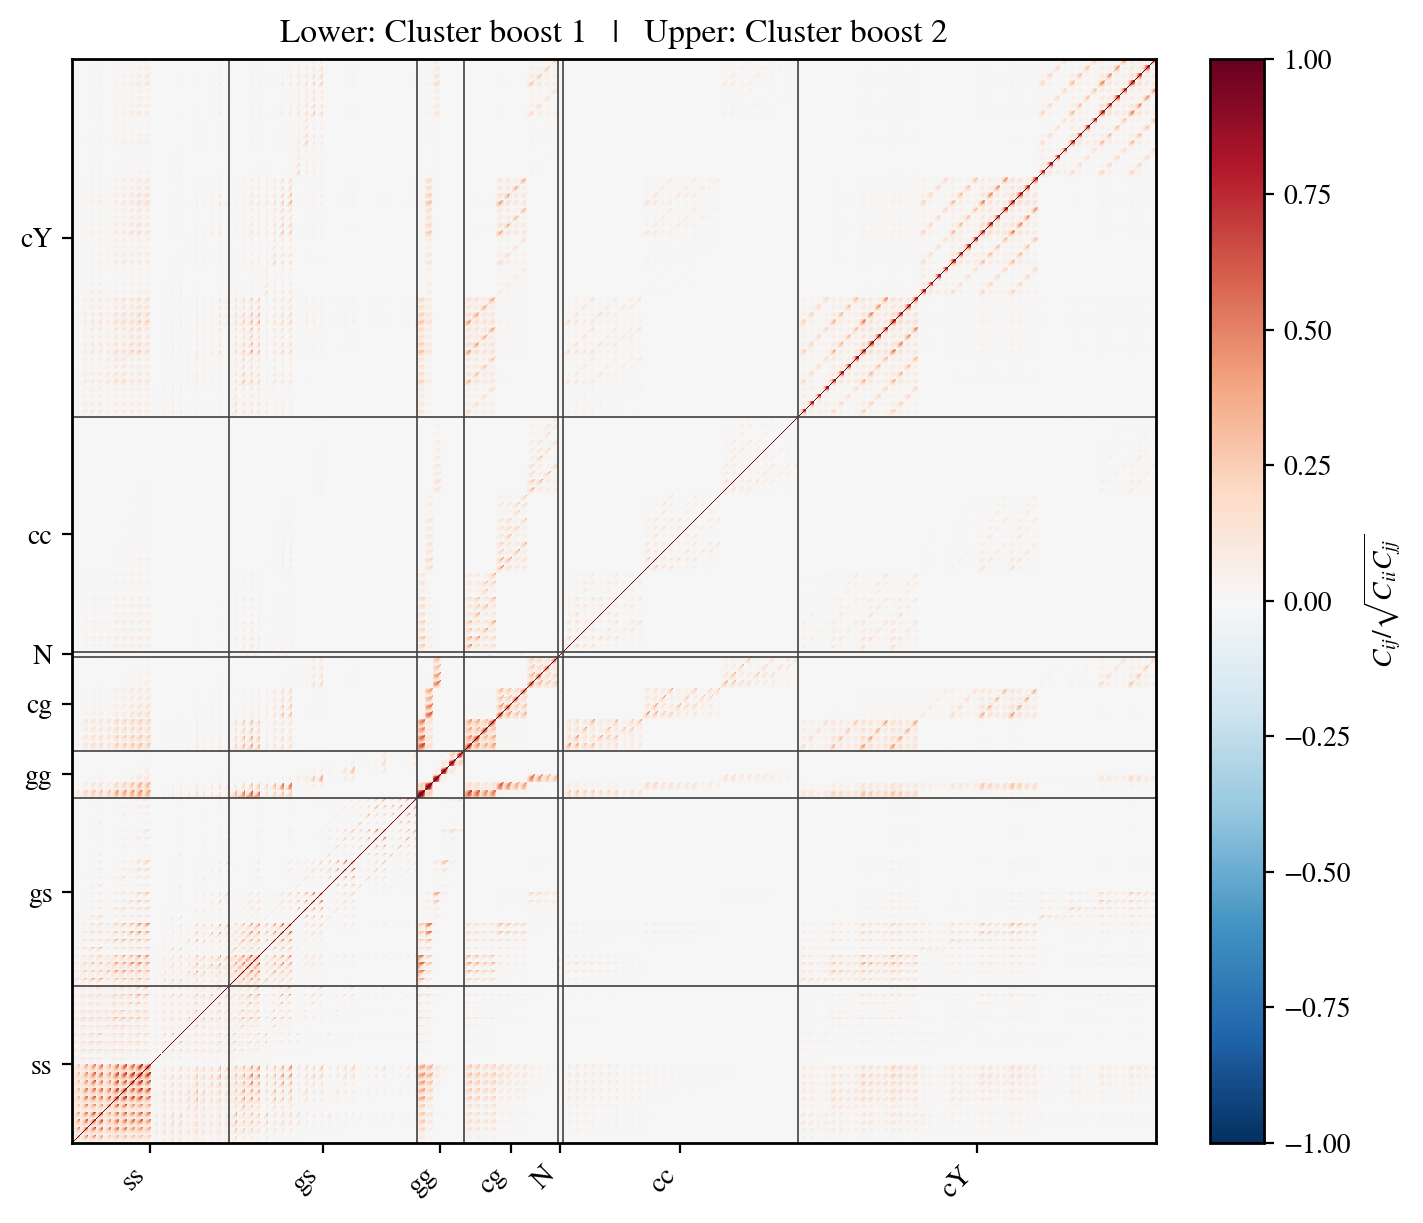

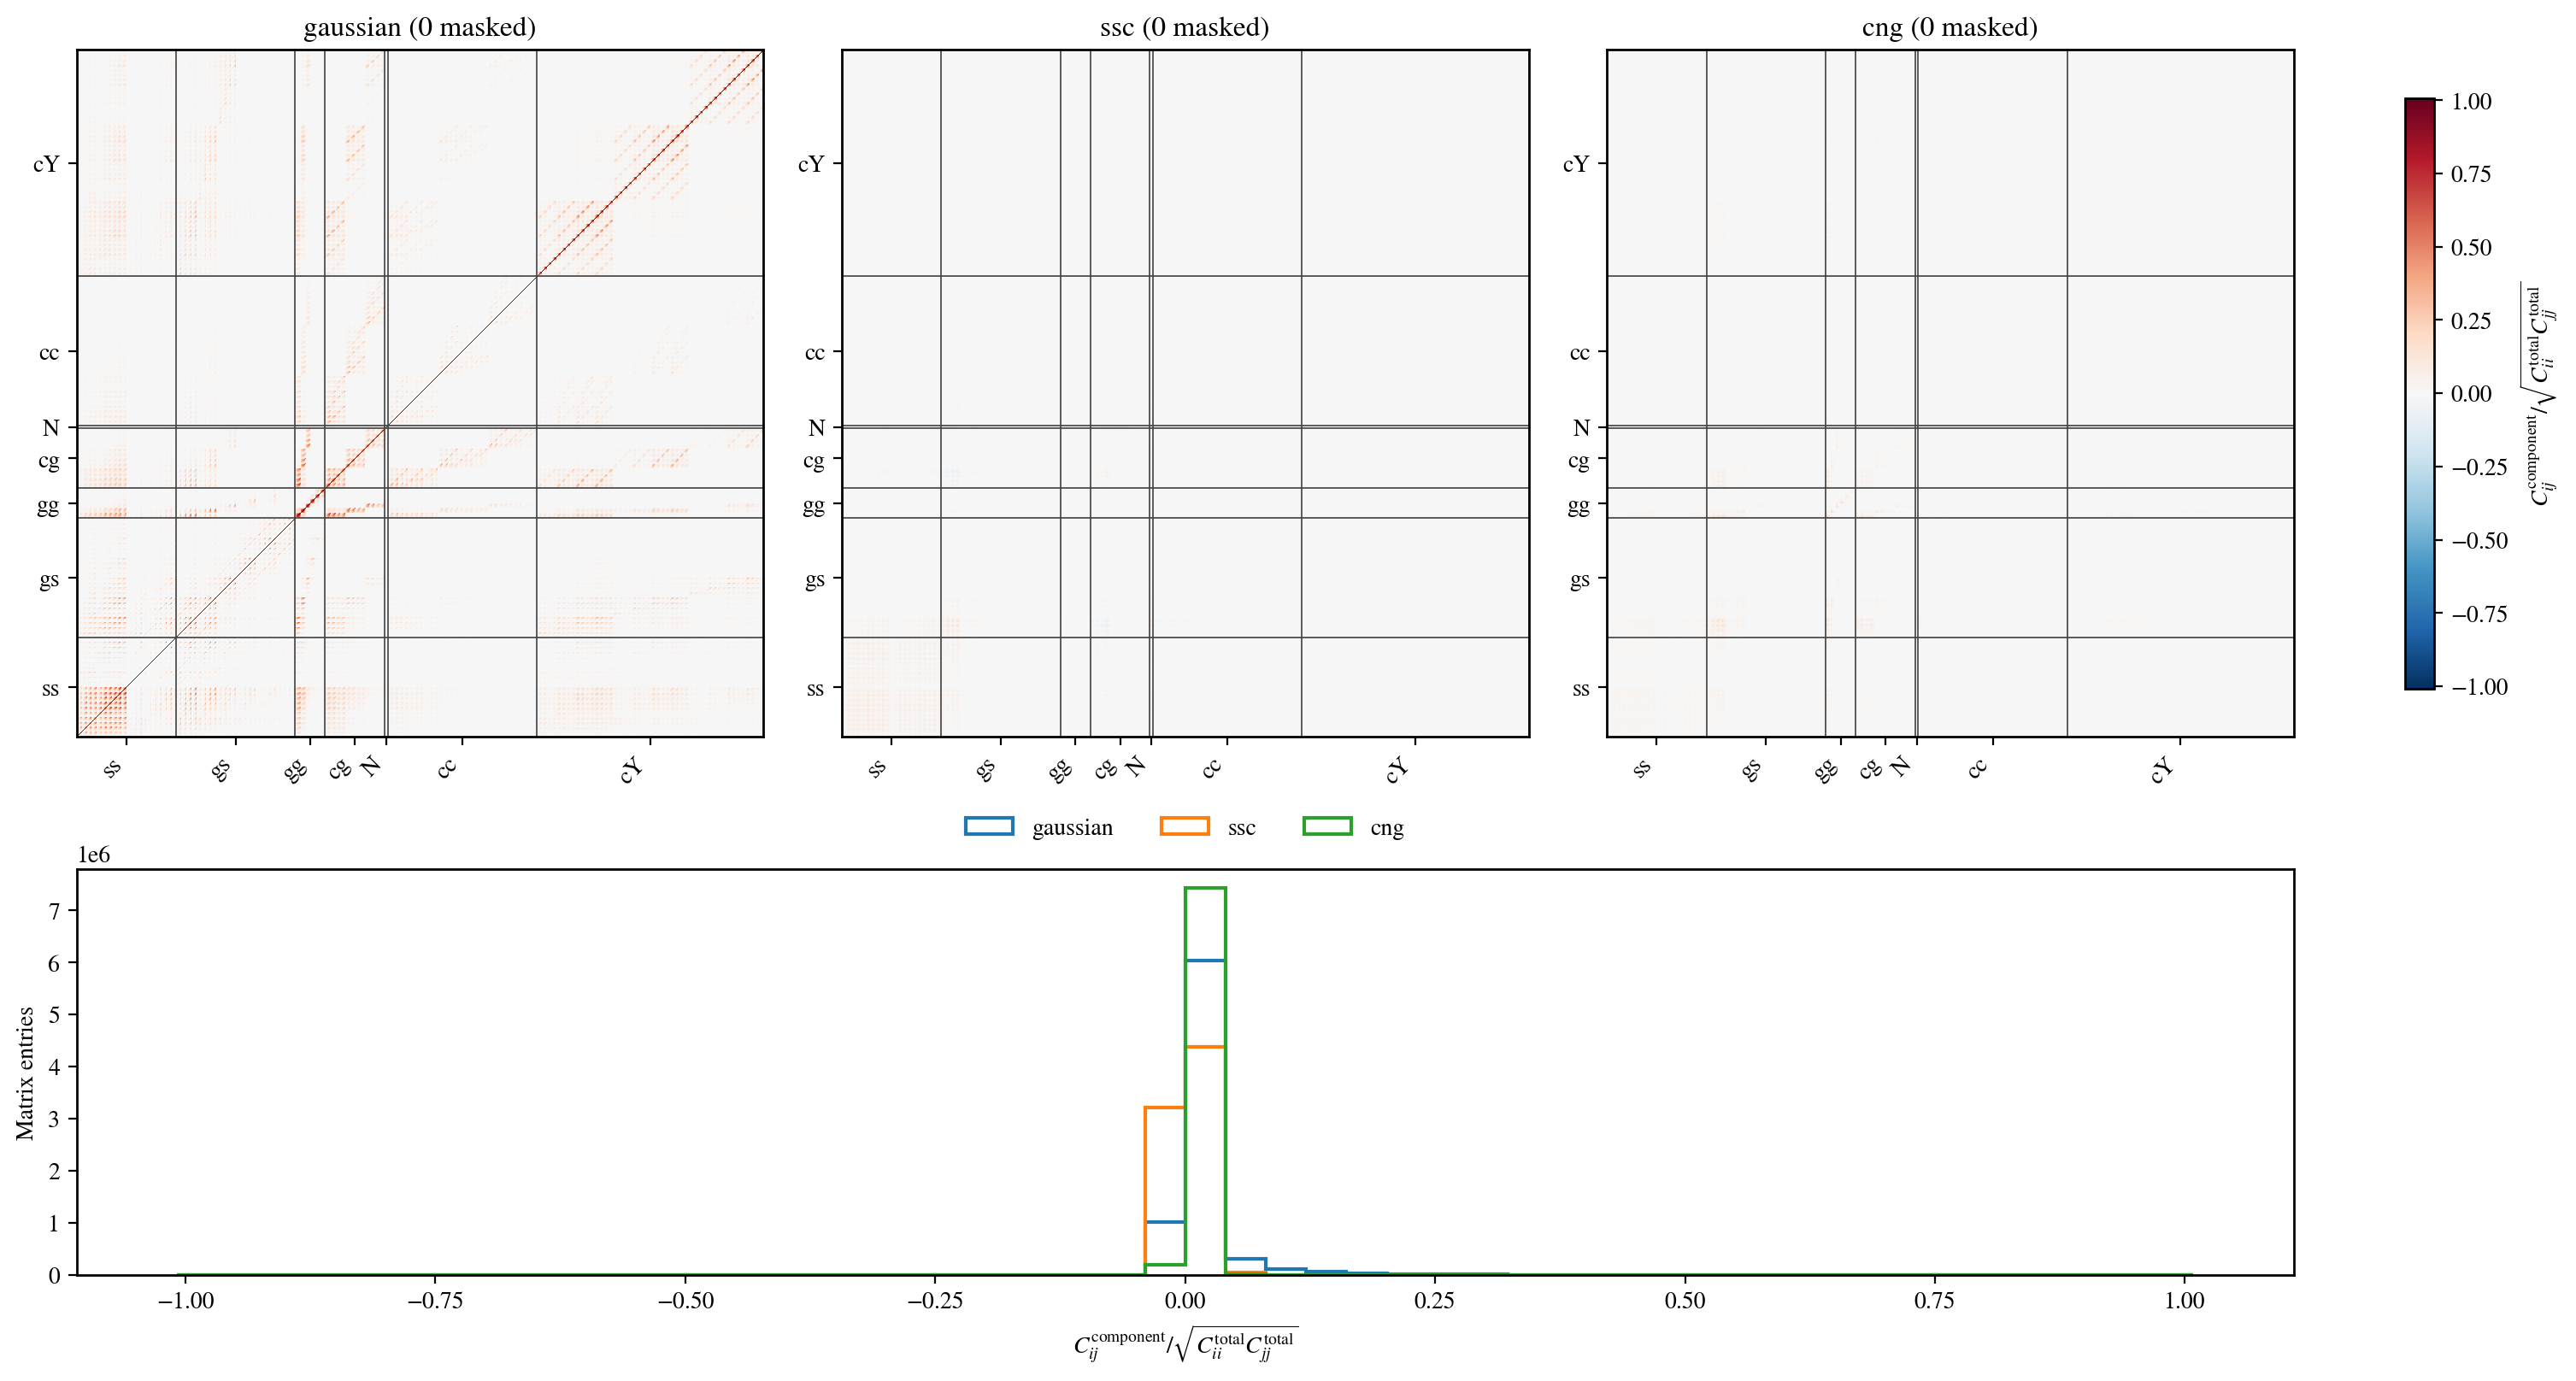

In [10]:
keep = joint["valid_indices"]
reference = joint["total"][np.ix_(keep, keep)]
for boost in cluster_boosts:
    matrix = joint_results[boost]["total"][np.ix_(keep, keep)]
    modes = cov.covariance_modes(matrix=matrix)
    change = cov.compare_covariances(matrix=matrix, reference=reference)
    print(boost, "positive:", modes["positive_definite"],
          "minimum correlation eigenvalue:", modes["correlation_eigenvalues"][0],
          "maximum variance change:", change["maximum_fractional_variance_change"])

# The final cluster-lensing block has 48 rows times 19 retained angles.
# Counts occupy their own 12-entry block between cg and cc.
block_sizes = [
    400,    # 20 shear-pair rows, including xi+ and xi-, times 20 angles
    480,    # 6 galaxy bins times 4 source bins times 20 angles
    120,    # 6 galaxy auto-correlations times 20 angles
    240,    # 12 cluster-galaxy rows times 20 angles
    12,     # 3 observed redshift bins times 4 richness bins
    600,    # 3 redshift bins times 10 richness pairs times 20 angles
    48*19,  # 48 cluster-lensing rows, each with its defined null bin removed
]
block_labels = [
    "ss",
    "gs",
    "gg",
    "cg",
    "N",
    "cc",
    "cY",
]
first = joint_results[cluster_boosts[0]]["total"][np.ix_(keep, keep)]
pcov.plot_correlation(
    covariance=first, covariance_ref=reference,
    block_sizes=block_sizes, block_labels=block_labels,
    labels=(f"Cluster boost {cluster_boosts[0]}",
            f"Cluster boost {cluster_boosts[-1]}"),
)
components = {}
for name in ("gaussian", "ssc", "cng"):
    components[name] = joint[name][np.ix_(keep, keep)]
pcov.plot_covariance_components(
    total=reference, components=components,
    block_sizes=block_sizes, block_labels=block_labels,
)


### Save the joint forecast

Save the full layout, including defined Y null rows, count positions,
mean signals and model omissions. The archive includes `valid_indices`
for diagnostic selection; physical likelihood cuts remain a separate
choice. Running this cell replaces only these computed forecast files.


In [11]:
save_joint_forecast(
    result=joint, filename=project/"covariance/forecast_cluster.npz",
)
np.savez(file=project/"covariance/forecast_cluster_camb.npz", **cluster_camb)
with np.load(project/"covariance/forecast_cluster.npz", allow_pickle=False) as saved:
    print("Saved joint arrays:", saved.files)


Saved joint arrays: ['gaussian', 'ssc', 'cng', 'total', 'rows', 'two_point_positions', 'count_positions', 'cluster_lensing_positions', 'signal', 'mean_counts', 'joint_signal', 'valid_indices', 'geometry', 'coarse_ell', 'pair_area_sr2', 'coordinate', 'coordinate_label', 'settings_json', 'stages_json']
